In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter

import pandas as pd
import seaborn as sns
import pickle
import json
import sys
sys.path.append('../')
from src.trajectory_utils import reconstruct_trajectory_from_canonical_pieces
import src.viz


def plot_microstate_graph(
    P, node_weights, position=None,
    node_top_frac=None,      # e.g. 0.01 to keep top 1% nodes
    node_min=None,           # absolute min weight to keep a node
    edge_top_frac=0.01,      # keep top X% edges among kept nodes
    edge_min=None,           # absolute min P_ij to keep an edge
    max_out_edges=None,      # optionally cap kept outgoing edges per node
    draw_self_loops=False,
    node_size_scale=3000, node_size_min=100,
    edge_width_scale=8.0,
    with_labels=False,
    ax=None,
):
    """
    P: (N,N) row-stochastic matrix.
    node_weights: (N,) nonnegative weights (e.g., counts, π, etc.).
    pos: optional node positions. dict {i:(x,y)} or array (N,2).
    """
    P = np.asarray(P, float)
    w = np.asarray(node_weights, float)
    N = P.shape[0]
    assert P.shape == (N, N) and w.shape == (N,)

    # --- select nodes ---
    keep = np.arange(N)
    if node_min is not None:
        keep = keep[w >= float(node_min)]
    if node_top_frac is not None:
        k = max(1, int(np.ceil(node_top_frac * N)))
        top_idx = np.argpartition(w, -k)[-k:]
        keep = np.intersect1d(keep, top_idx, assume_unique=False)
    if keep.size == 0:
        if ax is None:
            fig, ax = plt.subplots(figsize=(6, 5))
        else:
            fig = ax.figure
        ax.set_title("No nodes passed thresholds"); ax.axis('off')
        return fig, ax

    # submatrices / weights
    idx_map = {i: k for k, i in enumerate(keep)}
    subP = P[np.ix_(keep, keep)].copy()
    if not draw_self_loops:
        np.fill_diagonal(subP, 0.0)
    subw = w[keep]

    # --- select edges ---
    # global top-fraction filter
    sel = np.zeros_like(subP, dtype=bool)
    flat = subP.ravel()
    pos_mask = flat > 0
    if pos_mask.any():
        npos = int(pos_mask.sum())
        if edge_top_frac is not None:
            m = max(1, int(np.ceil(edge_top_frac * npos)))
            cutoff = np.partition(flat[pos_mask], -m)[-m]
        else:
            cutoff = -np.inf
        if edge_min is not None:
            cutoff = max(cutoff, float(edge_min))
        sel = subP >= cutoff

    # optional per-row cap
    if max_out_edges is not None and max_out_edges > 0:
        k = int(max_out_edges)
        for i in range(sel.shape[0]):
            row = subP[i]
            pos = np.nonzero(row > 0)[0]
            if pos.size > k:
                # keep k largest in this row
                topk_pos = pos[np.argpartition(row[pos], -k)[-k:]]
                keep_row = np.zeros_like(row, dtype=bool)
                keep_row[topk_pos] = True
                sel[i] &= keep_row

    # build graph
    G = nx.DiGraph()
    # node sizes (normalize to kept max)
    vmax = subw.max() if subw.size else 1.0
    sizes = node_size_min + node_size_scale * (subw / vmax if vmax > 0 else 0)
    for i_sub, i in enumerate(keep):
        G.add_node(int(i), size=float(sizes[i_sub]), weight=float(subw[i_sub]))

    edges, weights = [], []
    for i_sub, i in enumerate(keep):
        js = np.nonzero(sel[i_sub])[0]
        for j_sub in js:
            j = keep[j_sub]
            pij = float(subP[i_sub, j_sub])
            if pij > 0:
                G.add_edge(int(i), int(j), weight=pij)
                edges.append((int(i), int(j)))
                weights.append(pij)

    # positions
    if position is None:
        pos_draw = nx.kamada_kawai_layout(G, weight='weight')
    else:
        if isinstance(position, dict):
            pos_draw = {i: tuple(position[i]) for i in G.nodes if i in position}
        else:  # array (N,2)
            arr = np.asarray(position, float)
            pos_draw = {i: (arr[i, 0], arr[i, 1]) for i in G.nodes}

    # draw
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 6))
    else:
        fig = ax.figure
    N = G.number_of_nodes()
    face = np.tile([1.0, 1.0, 1.0, 0.], (N, 1))
    edgecolors = 'tab:red'
    nx.draw_networkx_nodes(
        G, pos_draw, ax=ax,
        node_size=[G.nodes[n]['size'] for n in G.nodes],
        node_color=face, edgecolors=edgecolors, linewidths=1.0
    )
    if with_labels:
        nx.draw_networkx_labels(
            G, pos_draw, ax=ax,
            labels={n: str(n) for n in G.nodes}, font_size=8
        )
    if edges:
        ws = np.array(weights, float)
        widths = edge_width_scale * (ws / ws.max())
        nx.draw_networkx_edges(
            G, pos_draw, ax=ax, edgelist=edges,
            width=widths, arrows=True, arrowstyle='-|>', arrowsize=10,
            connectionstyle='arc3,rad=0.08',alpha=0.7
        )

    #ax.set_title("Microstate graph (size ∝ weight, edge ∝ P_ij)")
    #ax.axis('off')
    pad = 4
    xs, ys = zip(*pos_draw.values())
    ax.set_xlim(min(xs)-pad, max(xs)+pad)
    ax.set_ylim(min(ys)-pad, max(ys)+pad)
    ax.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)


    return fig, ax


In [2]:
names = ['straight_helix']


data,embs,mkvs = list(),list(),list()
umap_points = list()
for name in names:
    data.append(np.load('../data/toy_model/processed/umap_centers_'+name+'.npy'))
    umap_points.append( (np.load('../data/toy_model/processed/umap_points_'+name+'.npy')))
    # Paths to data from embed_and_cluster.py
    with open("../data/toy_model/processed/embedding_"+name+".pkl", "rb") as f:
            embs.append(pickle.load(f))
    with open("../data/toy_model/processed/markov_"+name+".pkl", "rb") as f:
            mkvs.append(pickle.load(f))
taus = [10]
for i in range(names.__len__()):
        mkvs[i].tau = taus[i]
        mkvs[i].make_transition_matrix()

(array([48.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  1.]),
 array([4.50000e+01, 5.87370e+03, 1.17024e+04, 1.75311e+04, 2.33598e+04,
        2.91885e+04, 3.50172e+04, 4.08459e+04, 4.66746e+04, 5.25033e+04,
        5.83320e+04]),
 <BarContainer object of 10 artists>)

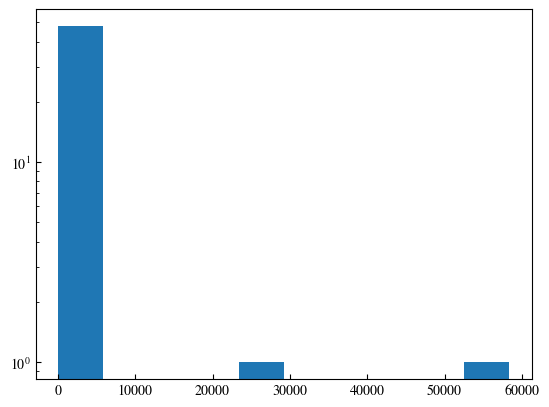

In [3]:
plt.hist(list(dict(Counter(embs[i].labels)).values()),log=True)

(array([2.435e+03, 2.000e+00, 1.000e+00, 7.000e+00, 5.000e+00, 5.000e+00,
        7.000e+00, 2.000e+00, 3.000e+00, 3.300e+01]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

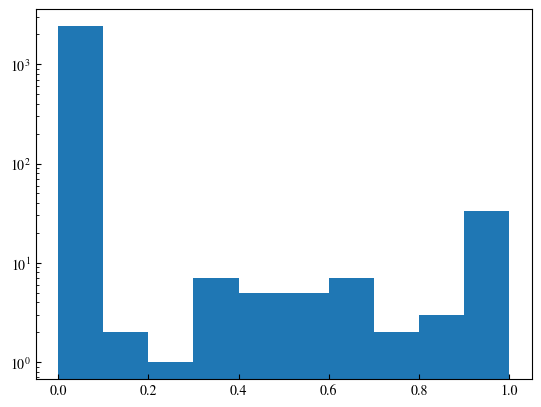

In [4]:
plt.hist(mkvs[0].P.flatten(),log=True)

In [10]:
print(data[0].shape)
print(mkvs[0].P.shape)
print(dict(Counter(embs[i].labels)))

weights = np.zeros(mkvs[0].P.shape[0],dtype=float)
for key,values in dict(Counter(embs[i].labels)).items():
    weights[key] = values

(50, 2)
(50, 50)
{0: 58332, 43: 272, 25: 236, 15: 245, 20: 90, 18: 167, 9: 155, 13: 185, 42: 233, 10: 611, 49: 611, 21: 239, 46: 115, 8: 202, 3: 499, 12: 779, 22: 697, 1: 28820, 41: 552, 16: 535, 6: 245, 27: 146, 29: 152, 31: 234, 23: 194, 17: 234, 35: 240, 36: 252, 26: 436, 34: 288, 30: 186, 4: 178, 48: 183, 45: 72, 39: 177, 19: 120, 7: 179, 5: 112, 47: 45, 32: 112, 38: 239, 37: 145, 28: 91, 14: 132, 40: 120, 44: 129, 2: 125, 24: 150, 11: 247, 33: 62}


In [11]:
stoch_mat = mkvs[0].P
#weight_tot = np.sum(weights)
#for i in range(stoch_mat.shape[0]):
#    stoch_mat[i] = stoch_mat[i] * weights[i]/weight_tot

print(stoch_mat.shape)
print(weights.shape)

(50, 50)
(50,)


/mnt/hcleroy/anaconda3/lib/python3.11/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/mnt/hcleroy/anaconda3/lib/python3.11/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


<ScatterDensityAxes: >

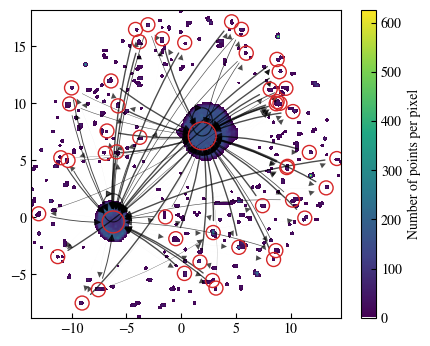

In [17]:
fig,ax = plt.subplots(figsize=(5,4),subplot_kw={'projection':'scatter_density'})

plot_microstate_graph(
    P = stoch_mat, node_weights = weights, position=data[0],
    node_top_frac=None,      # e.g. 0.01 to keep top 1% nodes
    node_min=None,           # absolute min weight to keep a node
    edge_top_frac=None,      # keep top X% edges among kept nodes
    edge_min=None,           # absolute min P_ij to keep an edge
    max_out_edges=None,      # optionally cap kept outgoing edges per node
    draw_self_loops=True,
    node_size_scale=300, node_size_min=100,
    edge_width_scale=1.0,
    with_labels=False,
    ax=ax)
src.viz.use_mpl_scatter_density(fig,umap_points[0][:,0],umap_points[0][:,1],ax=ax,dpi=50)
#fig.savefig('network_20percent_with_edges.svg',bbox_inches='tight')

In [9]:
names = ['fed_track']


data,embs,mkvs = list(),list(),list()
umap_points = list()
for name in names:
    data.append(np.load('../data/choano/processed/umap_centers_'+name+'.npy'))
    umap_points.append( (np.load('../data/choano/processed/umap_points_'+name+'.npy')))
    # Paths to data from embed_and_cluster.py
    with open("../data/choano/processed/embedding_"+name+".pkl", "rb") as f:
            embs.append(pickle.load(f))
    with open("../data/choano/processed/markov_"+name+".pkl", "rb") as f:
            mkvs.append(pickle.load(f))
taus = [10]
for i in range(names.__len__()):
        mkvs[i].tau = taus[i]
        mkvs[i].make_transition_matrix()

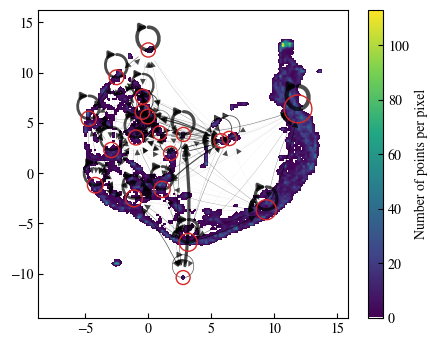

In [29]:
weights = np.zeros(embs[i].n_clusters,dtype=float)
for key,values in dict(Counter(embs[i].labels)).items():
    weights[key] = values
stoch_mat = mkvs[0].P
fig,ax = plt.subplots(figsize=(5,4),subplot_kw={'projection':'scatter_density'})
src.viz.use_mpl_scatter_density(fig,umap_points[0][:,0],umap_points[0][:,1],ax=ax,dpi=50)
ax = plot_microstate_graph(
    P = stoch_mat, node_weights = weights, position=data[0],
    node_top_frac=None,      # e.g. 0.01 to keep top 1% nodes
    node_min=None,           # absolute min weight to keep a node
    edge_top_frac=None,      # keep top X% edges among kept nodes
    edge_min=None,           # absolute min P_ij to keep an edge
    max_out_edges=None,      # optionally cap kept outgoing edges per node
    draw_self_loops=True,
    node_size_scale=300, node_size_min=100,
    edge_width_scale=3.0,
    with_labels=False,
    ax=ax)

fig.savefig('network_choano.svg',bbox_inches='tight')